In [18]:
import pandas as pd

# Load the CSV file
file_path = 'evaluation_results.csv'  # Change this to your actual file path
data = pd.read_csv(file_path)




In [19]:
# Filter data by Evaluation Type
single_feature_data = data[data['Evaluation_Type'] == 'Single Feature']
incremental_feature_data = data[data['Evaluation_Type'].str.contains('Incremental')]

# Find the best single feature based on the lowest MAE
best_single_feature = single_feature_data.loc[single_feature_data['Mean_Absolute_Error'].idxmin()]
print("Best Single Feature Analysis:")
print(f"Feature: {best_single_feature['Features']}, MAE: {best_single_feature['Mean_Absolute_Error']}\n")



Best Single Feature Analysis:
Feature: RH, MAE: 0.0684697106480598



In [20]:
#  incremental feature sets
# average MAE difference for each set
incremental_avg_mae_diff = (
    incremental_feature_data.groupby(['Evaluation_Type', 'Features'])
    ['Mean_Absolute_Error_Diff']
    .mean()
    .reset_index()
    .sort_values(by='Mean_Absolute_Error_Diff')
)



In [21]:
#  top incremental feature sets with the lowest average MAE difference
top_incremental_features = incremental_avg_mae_diff.head(10)  # Top 10 feature sets by lowest MAE diff
print(top_incremental_features)



Top Incremental Feature Sets Based on Average MAE Difference:
                Evaluation_Type  \
9    Incremental top_1_features   
16   Incremental top_8_features   
12   Incremental top_4_features   
6   Incremental top_16_features   
0   Incremental top_10_features   
4   Incremental top_14_features   
11   Incremental top_3_features   
17   Incremental top_9_features   
3   Incremental top_13_features   
13   Incremental top_5_features   

                                             Features  \
9                                 1, features, ['RH']   
16  8, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 20...   
12   4, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 20']   
6   16, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 2...   
0   10, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 2...   
4   14, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 2...   
11              3, features, ['RH', 'Ppt', 'SWC, 10']   
17  9, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 20...   
3   13, features, ['RH', 'Ppt', 'SWC, 1

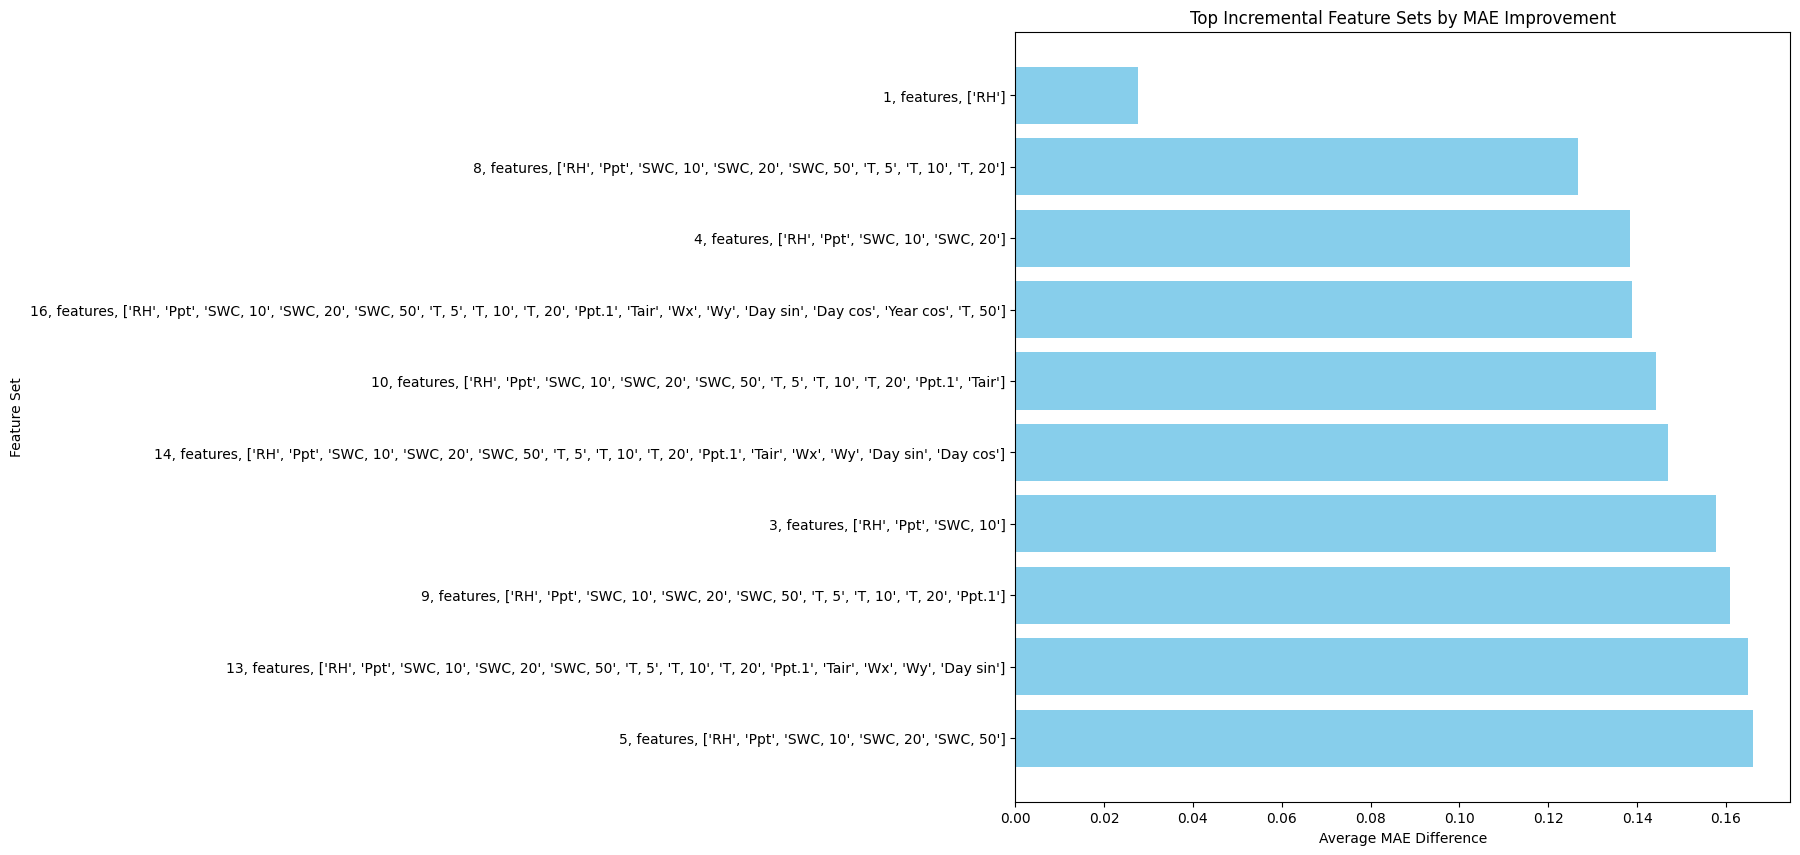

In [23]:
# Plotting the best incremental feature sets
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.barh(
    top_incremental_features['Features'],
    top_incremental_features['Mean_Absolute_Error_Diff'],
    color='skyblue'
)
plt.xlabel('Average MAE Difference')
plt.ylabel('Feature Set')
plt.title('Top Incremental Feature Sets by MAE Improvement')
plt.gca().invert_yaxis()
plt.show()



In [24]:
# Further analysis of the best model for each top incremental feature set
for index, row in top_incremental_features.iterrows():
    feature_set = row['Features']
    subset = incremental_feature_data[incremental_feature_data['Features'] == feature_set]
    best_model = subset.loc[subset['Mean_Absolute_Error_Diff'].idxmin()]
    print(f"\nBest model for {feature_set}:")
    print(f"Model: {best_model['Model']}, MAE Diff: {best_model['Mean_Absolute_Error_Diff']}, Original MAE: {best_model['original_mae']}")


Best model for 1, features, ['RH']:
Model: Autoregressive, MAE Diff: -0.2396473288536071, Original MAE: 0.4329587519168854

Best model for 8, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 20', 'SWC, 50', 'T, 5', 'T, 10', 'T, 20']:
Model: Bi-LSTM, MAE Diff: -0.3461199402809143, Original MAE: 1.1800607442855835

Best model for 4, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 20']:
Model: Bi-LSTM, MAE Diff: -0.3215277194976806, Original MAE: 1.1800607442855835

Best model for 16, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 20', 'SWC, 50', 'T, 5', 'T, 10', 'T, 20', 'Ppt.1', 'Tair', 'Wx', 'Wy', 'Day sin', 'Day cos', 'Year cos', 'T, 50']:
Model: Bi-LSTM, MAE Diff: -0.3330040574073791, Original MAE: 1.1800607442855835

Best model for 10, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 20', 'SWC, 50', 'T, 5', 'T, 10', 'T, 20', 'Ppt.1', 'Tair']:
Model: Autoregressive, MAE Diff: -0.2212682068347931, Original MAE: 0.4329587519168854

Best model for 14, features, ['RH', 'Ppt', 'SWC, 10', 'SWC, 20', 'SWC, 50', 'T, 5'

In [26]:
df = pd.read_csv('evaluation_results.csv')

incremental_df = df[df['Evaluation_Type'].str.contains('Incremental')]

# Sort by the MAE difference to find the combinations that reduce the MAE the most
# The lowest Mean_Absolute_Error_Diff signifies the highest positive impact
top_combinations = incremental_df.sort_values(by='Mean_Absolute_Error_Diff').head(10)

In [1]:
top_combinations

NameError: name 'top_combinations' is not defined